# EP1 — StreamView Analytics
## Limpieza y Análisis Exploratorio (EDA) — Dataset `Data_Movies`

**Curso:** ADY1104 – Visualización de Datos
**Caso:** StreamView Analytics — Evaluación Parcial I (Semana 5)
**Alcance de este notebook:** exclusivamente el dataset *Netflix Movies Detailed up to 2025* (`Data_Movies`), conforme a lo solicitado en la Evaluación Parcial I.

Este notebook documenta:
1. Revisión de calidad de los datos (nulos, duplicados, formatos, categorías, outliers, coherencia presupuesto/ingresos).
2. Transformaciones aplicadas, **justificadas** (no se modifica el archivo original; se trabaja sobre una copia en memoria y se exporta un CSV limpio aparte).
3. Análisis exploratorio orientado a las preguntas de negocio del caso (catálogo, popularidad, valoración, producción, rentabilidad).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 20)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ============================================================
# BUSCAR DATASET
# ============================================================

# Ubicación actual del notebook
BASE_DIR = Path.cwd()

print("Carpeta actual:")
print(BASE_DIR)

# Subir desde /notebooks a /netflix-visual
PROJECT_DIR = BASE_DIR.parent

# Entrar a /data
DATA_DIR = PROJECT_DIR / "data"

# Dataset
dataset_path = DATA_DIR / "netflix_movies_detailed_up_to_2025.csv"

print("\nBuscando dataset en:")
print(dataset_path)

# Verificar si existe
if not dataset_path.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset en:\n{dataset_path}"
    )

print("\n✅ Dataset encontrado correctamente.")

# ============================================================
# CARGAR DATASET
# ============================================================

df = pd.read_csv(dataset_path)

print("\nDimensiones:", df.shape)

print("\nPrimeras filas:")
display(df.head())

print("\nTipos de datos:")
print(df.dtypes)

Carpeta actual:
c:\Users\Roma\Documents\proyectos dudoc\netflix-visual\notebooks

Buscando dataset en:
c:\Users\Roma\Documents\proyectos dudoc\netflix-visual\data\netflix_movies_detailed_up_to_2025.csv

✅ Dataset encontrado correctamente.

Dimensiones: (16000, 18)

Primeras filas:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471



Tipos de datos:
show_id           int64
type                str
title               str
director            str
cast                str
country             str
date_added          str
release_year      int64
rating          float64
duration        float64
genres              str
language            str
description         str
popularity      float64
vote_count        int64
vote_average    float64
budget            int64
revenue           int64
dtype: object


## 1. Calidad de los Datos

In [2]:

# 1.1 Valores nulos por columna
nulos = df.isnull().sum().sort_values(ascending=False)
pct = (nulos / len(df) * 100).round(1)
resumen_nulos = pd.DataFrame({'nulos': nulos, '% nulos': pct})
print(resumen_nulos[resumen_nulos['nulos'] > 0])


             nulos  % nulos
duration     16000    100.0
country        466      2.9
cast           204      1.3
director       132      0.8
description    132      0.8
genres         107      0.7


In [3]:

# 1.2 Registros duplicados
print("Filas 100% duplicadas:", df.duplicated().sum())
print("show_id duplicados:", df['show_id'].duplicated().sum())


Filas 100% duplicadas: 0
show_id duplicados: 0


In [4]:

# 1.3 Variable 'type': se confirma que este archivo contiene SOLO películas
print("Valores de 'type':", df['type'].unique())


Valores de 'type': <StringArray>
['Movie']
Length: 1, dtype: str


In [5]:

# 1.4 HALLAZGO IMPORTANTE: la columna 'rating' documentada en el diccionario del caso
# como "clasificación por edad" (TV-MA, PG-13, R, etc.) en realidad NO contiene esos
# valores en este extracto: contiene números decimales.
print("Muestra de 'rating':", df['rating'].head().tolist())
print()
coincide = (df['rating'] == df['vote_average']).all()
print(f"¿'rating' es idéntico a 'vote_average' en el 100% de las filas? {coincide}")


Muestra de 'rating': [6.38, 8.369, 7.744, 7.6, 7.8]

¿'rating' es idéntico a 'vote_average' en el 100% de las filas? True


In [6]:

# 1.5 HALLAZGO IMPORTANTE: la columna 'duration' está completamente vacía en este extracto
print("Nulos en 'duration':", df['duration'].isnull().sum(), "de", len(df),
      f"({df['duration'].isnull().mean()*100:.1f}%)")
print("Valores no nulos encontrados:", df['duration'].dropna().unique()[:5])


Nulos en 'duration': 16000 de 16000 (100.0%)
Valores no nulos encontrados: []


In [7]:

# 1.6 Coherencia budget / revenue (Regla de Negocio: aplican solo a películas)
print("budget == 0:", (df['budget'] == 0).sum(), f"({(df['budget']==0).mean()*100:.1f}%)")
print("revenue == 0:", (df['revenue'] == 0).sum(), f"({(df['revenue']==0).mean()*100:.1f}%)")
print("budget y revenue ambos == 0:", ((df['budget']==0) & (df['revenue']==0)).sum())
b_tmp = df['budget'].replace(0, np.nan)
r_tmp = df['revenue'].replace(0, np.nan)
usables = (b_tmp.notna() & r_tmp.notna()).sum()
print(f"Películas con budget Y revenue realmente informados: {usables} ({usables/len(df)*100:.1f}%)")


budget == 0: 11153 (69.7%)
revenue == 0: 10355 (64.7%)
budget y revenue ambos == 0: 9048
Películas con budget Y revenue realmente informados: 3540 (22.1%)


In [8]:

# 1.7 Outliers en vote_average (Regla de negocio: escala 0-10)
fuera_de_escala = df[(df['vote_average'] < 0) | (df['vote_average'] > 10)]
print("vote_average fuera de rango 0-10:", len(fuera_de_escala))
print(df[['popularity','vote_count','vote_average']].describe())


vote_average fuera de rango 0-10: 0
         popularity    vote_count  vote_average
count  16000.000000  16000.000000  16000.000000
mean      20.384728    718.656125      5.956368
std       68.610033   2080.198316      1.754741
min        3.860000      0.000000      0.000000
25%        7.840750     53.000000      5.600000
50%       10.913500    138.000000      6.300000
75%       17.336500    422.000000      6.923000
max     3876.006000  37119.000000     10.000000


## 2. Transformaciones Documentadas y Justificadas

Con base en el diagnóstico anterior, se aplican las siguientes transformaciones sobre una **copia** del dataset (`df_clean`). El archivo original no se modifica (se respeta el Supuesto del Proyecto: "trabajar exclusivamente con los datos proporcionados, sin modificar su estructura original").

| # | Hallazgo de calidad | Transformación / Decisión | Justificación |
|---|---|---|---|
| 1 | `duration` está 100% vacía (16.000/16.000 filas) | Se **excluye** del análisis de duración/formato. No se puede imputar sin inventar datos. | El Diccionario de Datos del caso describe esta variable como texto tipo "120 min", pero en este extracto no contiene ningún valor utilizable. Se declara como limitación explícita (Regla de Negocio #9). |
| 2 | `rating` coincide 100% con `vote_average`, no corresponde a una clasificación por edad (TV-MA, PG-13, etc.) como indica el diccionario | Se **excluye** `rating` de los análisis de clasificación etaria; se documenta la discrepancia | Usarla como clasificación por edad induciría a conclusiones falsas para Marketing/Directorio. Es una inconsistencia entre la documentación del caso y los datos entregados. |
| 3 | `budget`/`revenue` en 0 en 69.7% / 64.7% de las filas | Se recodifican a **NaN** (no se tratan como presupuesto/ingreso real de $0) | En datasets tipo TMDB, 0 representa dato no informado. Mantenerlo en 0 distorsionaría promedios, sumas y ROI. |
| 4 | Solo ~22% del catálogo tiene budget y revenue simultáneamente disponibles | Los indicadores financieros (KPIs Financieros, ROI) se calculan **solo** sobre ese subconjunto, y se indica explícitamente el alcance en cada visualización | Regla de Negocio #6 y #9 del caso: los contenidos sin presupuesto/ingresos no deben considerarse en indicadores financieros. |
| 5 | `genres` y `country` son campos multivaluados (separados por coma) | Se generan vistas "explotadas" (una fila por género / por país) solo para los análisis que las requieren | Necesario para conteos y promedios por categoría; no se altera el dataset base. |
| 6 | `director`, `cast`, `country`, `genres`, `description` tienen nulos (0.7%–2.9%) | Se excluyen fila a fila **solo** del análisis puntual que use esa variable | No se eliminan del dataset completo para no perder cobertura del catálogo general. |
| 7 | Duplicados por `show_id` | Verificado: **no existen** duplicados en este extracto | Se documenta el chequeo (Regla de Negocio #1: cada registro es un único contenido). |


In [9]:
# Eliminar duplicados por show_id
df_clean = df.drop_duplicates(subset='show_id', keep='first').copy()

# Budget/revenue: 0 = dato no informado, no presupuesto real de $0
df_clean['budget'] = df_clean['budget'].replace(0, np.nan)
df_clean['revenue'] = df_clean['revenue'].replace(0, np.nan)

# ROI solo cuando budget > 10.000
# Esto evita ratios artificialmente extremos
df_clean['roi'] = np.where(
    df_clean['budget'] > 10000,
    df_clean['revenue'] / df_clean['budget'],
    np.nan
)

# 'duration' y 'rating' quedan marcados como no confiables
# No se eliminan las columnas, pero no se utilizan en el EDA.

print("Filas tras verificación de duplicados:", len(df_clean))

roi_validos = df_clean['roi'].notna().sum()
porcentaje_roi = df_clean['roi'].notna().mean() * 100

print(
    "Películas con datos financieros utilizables para ROI:",
    roi_validos,
    f"({porcentaje_roi:.1f}% del catálogo)"
)

# ============================================================
# GUARDAR DATASET LIMPIO
# ============================================================

df_clean.to_csv('../data/movies_clean.csv', index=False)

print("✅ Guardado correctamente en: ../data/movies_clean.csv")

Filas tras verificación de duplicados: 16000
Películas con datos financieros utilizables para ROI: 3524 (22.0% del catálogo)
✅ Guardado correctamente en: ../data/movies_clean.csv


## 3. Análisis Exploratorio (EDA)

Distribución de películas por año:
release_year
2010    1000
2011    1000
2012    1000
2013    1000
2014    1000
2015    1000
2016    1000
2017    1000
2018    1000
2019    1000
2020    1000
2021    1000
2022    1000
2023    1000
2024    1000
2025    1000
Name: count, dtype: int64


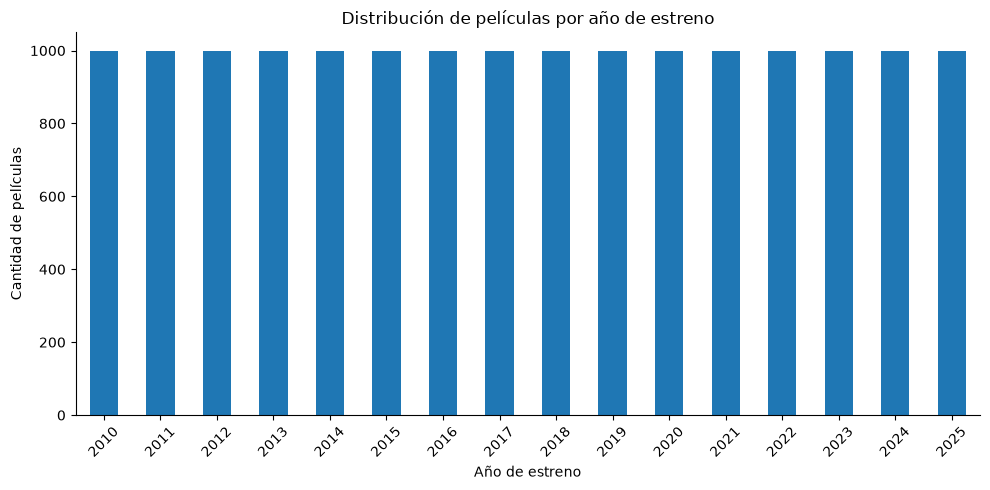

In [17]:
# 3.1 Distribución del catálogo por año de estreno

por_anio = (
    df_clean['release_year']
    .value_counts()
    .sort_index()
)

print("Distribución de películas por año:")
print(por_anio)

fig, ax = plt.subplots(figsize=(10, 5))

por_anio.plot(
    kind='bar',
    ax=ax
)

ax.set_title('Distribución de películas por año de estreno')
ax.set_xlabel('Año de estreno')
ax.set_ylabel('Cantidad de películas')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

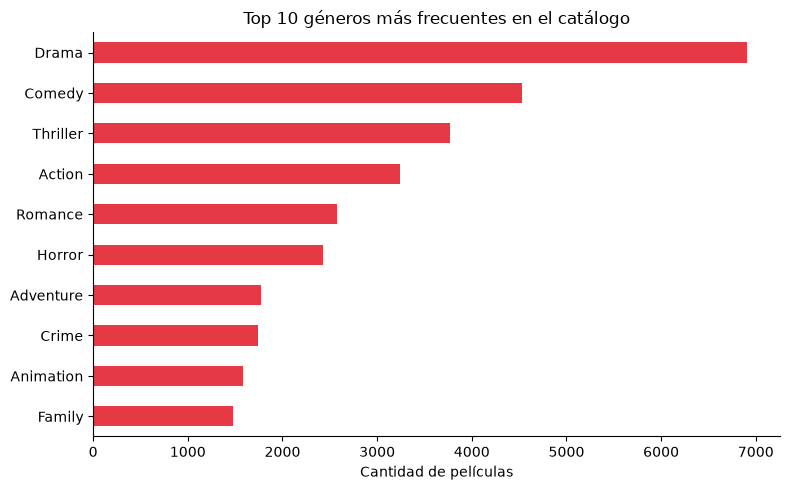

In [11]:

# 3.2 Top 10 géneros más frecuentes
generos = df_clean['genres'].dropna().str.split(', ').explode()
top_generos = generos.value_counts().head(10)

fig, ax = plt.subplots(figsize=(8,5))
top_generos.sort_values().plot(kind='barh', ax=ax, color='#E63946')
ax.set_title('Top 10 géneros más frecuentes en el catálogo')
ax.set_xlabel('Cantidad de películas')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


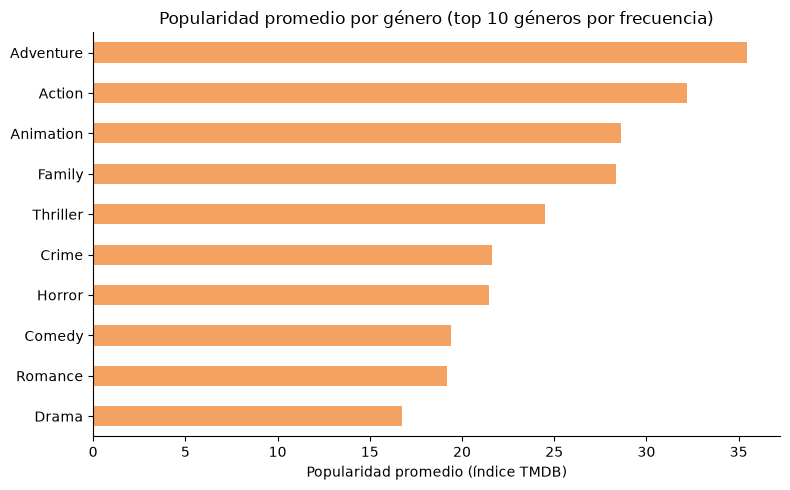

In [12]:

# 3.3 Popularidad promedio por género (top 10 por frecuencia)
df_gen = df_clean[['genres','popularity']].dropna().copy()
df_gen['genres'] = df_gen['genres'].str.split(', ')
df_gen = df_gen.explode('genres')
pop_por_genero = df_gen[df_gen['genres'].isin(top_generos.index)].groupby('genres')['popularity'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8,5))
pop_por_genero.plot(kind='barh', ax=ax, color='#F4A261')
ax.set_title('Popularidad promedio por género (top 10 géneros por frecuencia)')
ax.set_xlabel('Popularidad promedio (índice TMDB)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


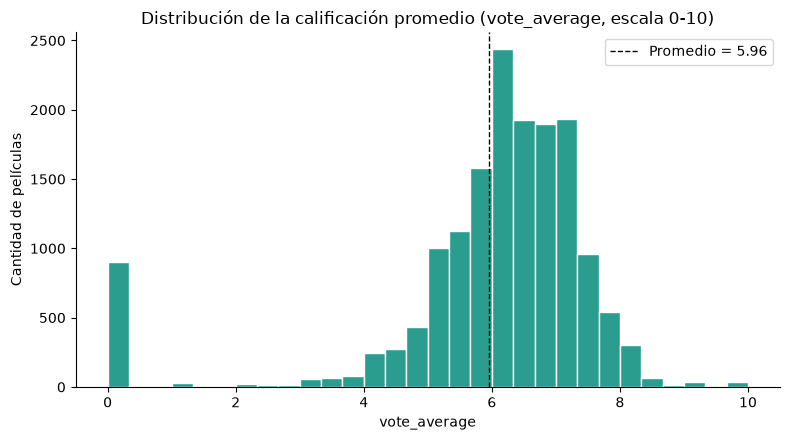

In [13]:

# 3.4 Distribución de vote_average (valoración del público)
fig, ax = plt.subplots(figsize=(8,4.5))
ax.hist(df_clean['vote_average'].dropna(), bins=30, color='#2A9D8F', edgecolor='white')
ax.axvline(df_clean['vote_average'].mean(), color='black', linestyle='--', linewidth=1,
           label=f"Promedio = {df_clean['vote_average'].mean():.2f}")
ax.set_title('Distribución de la calificación promedio (vote_average, escala 0-10)')
ax.set_xlabel('vote_average')
ax.set_ylabel('Cantidad de películas')
ax.legend()
plt.tight_layout()
plt.show()


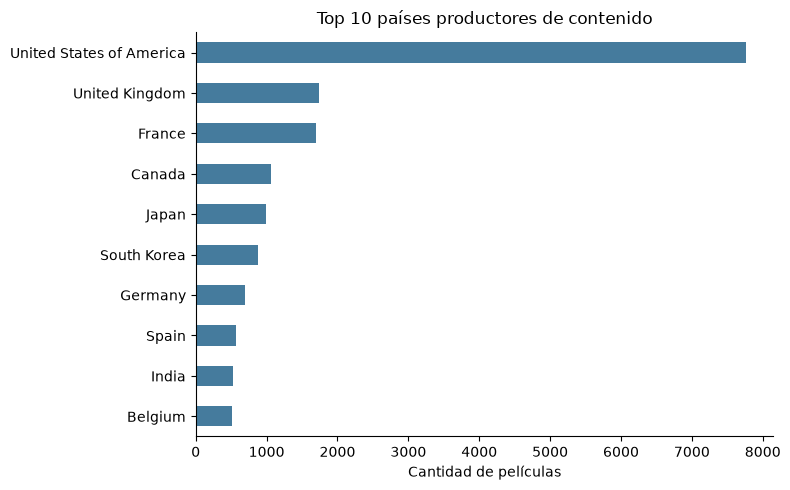

In [14]:

# 3.5 Top 10 países productores
paises = df_clean['country'].dropna().str.split(', ').explode()
top_paises = paises.value_counts().head(10)

fig, ax = plt.subplots(figsize=(8,5))
top_paises.sort_values().plot(kind='barh', ax=ax, color='#457B9D')
ax.set_title('Top 10 países productores de contenido')
ax.set_xlabel('Cantidad de películas')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


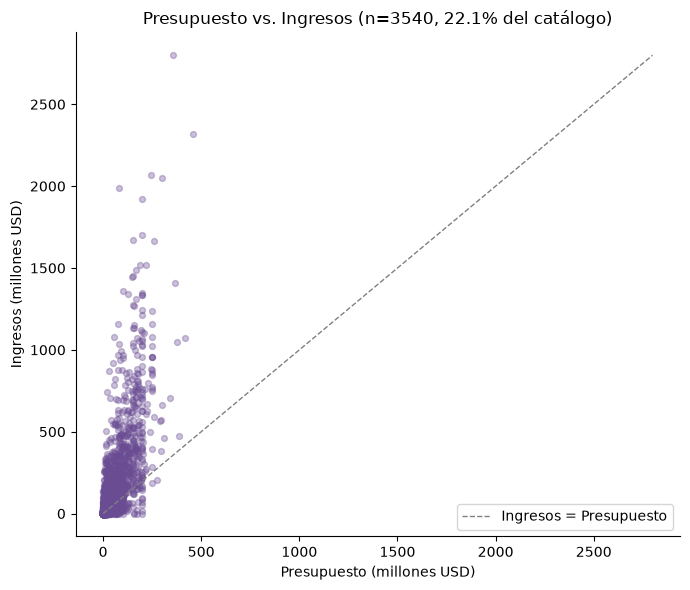

Correlación budget-revenue: 0.75
Películas con datos financieros completos: 3540 de 16000 (22.1%)


In [18]:
# 3.6 Relación presupuesto vs. ingresos

datos_fin = df_clean.dropna(
    subset=['budget', 'revenue']
)

porcentaje_fin = len(datos_fin) / len(df_clean) * 100

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    datos_fin['budget'] / 1e6,
    datos_fin['revenue'] / 1e6,
    alpha=0.35,
    s=18,
    color='#6A4C93'
)

lim = max(
    datos_fin['budget'].max(),
    datos_fin['revenue'].max()
) / 1e6

ax.plot(
    [0, lim],
    [0, lim],
    color='gray',
    linestyle='--',
    linewidth=1,
    label='Ingresos = Presupuesto'
)

ax.set_title(
    f'Presupuesto vs. Ingresos '
    f'(n={len(datos_fin)}, {porcentaje_fin:.1f}% del catálogo)'
)

ax.set_xlabel('Presupuesto (millones USD)')
ax.set_ylabel('Ingresos (millones USD)')

ax.legend()

plt.tight_layout()
plt.show()

# Correlación
corr = datos_fin[['budget', 'revenue']].corr().iloc[0, 1]

print(f"Correlación budget-revenue: {corr:.2f}")

print(
    f"Películas con datos financieros completos: "
    f"{len(datos_fin)} de {len(df_clean)} "
    f"({porcentaje_fin:.1f}%)"
)

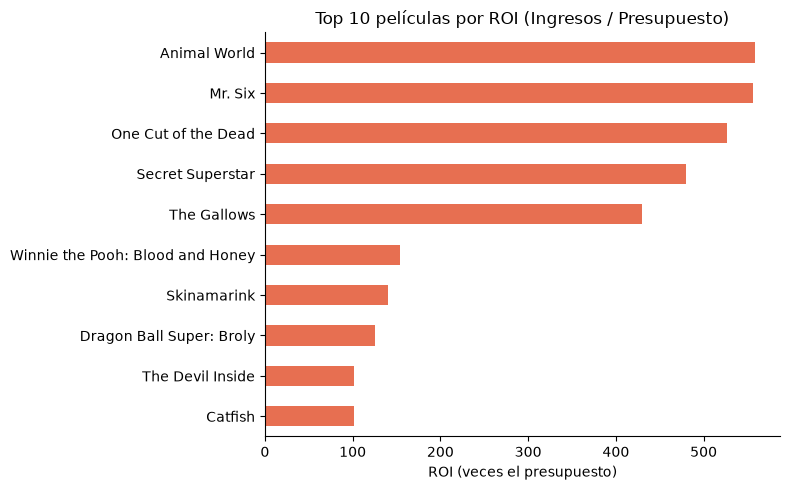

                           title    budget     revenue        roi
                    Animal World  125000.0  69885700.0 559.085600
                         Mr. Six  250000.0 139191345.0 556.765380
             One Cut of the Dead   52406.0  27590180.0 526.469870
                Secret Superstar  286284.0 137416709.0 480.001359
                     The Gallows  100000.0  42964410.0 429.644100
Winnie the Pooh: Blood and Honey   50000.0   7717044.0 154.340880
                     Skinamarink   15000.0   2100000.0 140.000000
        Dragon Ball Super: Broly 1000000.0 125002821.0 125.002821
                The Devil Inside 1000000.0 101800000.0 101.800000
                         Catfish   30000.0   3045943.0 101.531433


In [16]:

# 3.7 Top 10 películas por ROI (con presupuesto > 10.000 para evitar outliers artificiales)
top_roi = df_clean.dropna(subset=['roi']).sort_values('roi', ascending=False).head(10)[['title','budget','revenue','roi']]
top_roi_plot = top_roi.set_index('title')['roi'].sort_values()

fig, ax = plt.subplots(figsize=(8,5))
top_roi_plot.plot(kind='barh', ax=ax, color='#E76F51')
ax.set_title('Top 10 películas por ROI (Ingresos / Presupuesto)')
ax.set_xlabel('ROI (veces el presupuesto)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()
print(top_roi.to_string(index=False))


## 4. Principales Hallazgos

### Hallazgos de calidad de datos

- `duration` está **100% vacía** en este extracto, por lo que no es posible realizar un análisis de duración de las películas.
- `rating` **no corresponde a una clasificación por edad**, ya que coincide exactamente con `vote_average`. Por esta razón, no se utiliza para segmentar la audiencia por edad.
- Los valores 0 de `budget` y `revenue` se consideran datos no informados y se transforman en `NaN`.
- Solo una parte del catálogo dispone simultáneamente de presupuesto e ingresos, por lo que los análisis financieros tienen un alcance parcial.
- No se detectaron duplicados por `show_id`.

### Hallazgos de negocio

- El catálogo presenta una **distribución uniforme entre 2010 y 2025**, con aproximadamente 1.000 películas por año. Esta característica limita el análisis de tendencias temporales, ya que no permite identificar un crecimiento o disminución real del catálogo.
- **Drama** es el género con mayor presencia en el catálogo, seguido por Comedy y Thriller.
- El género más frecuente no necesariamente es el más popular. **Adventure** presenta la mayor popularidad promedio entre los principales géneros analizados.
- La calificación promedio del catálogo es de aproximadamente **5,96 sobre 10**, con una concentración importante de películas en valores medios y medios-altos.
- La producción está geográficamente concentrada en pocos países, destacando ampliamente **Estados Unidos**.
- Existe una relación positiva entre presupuesto e ingresos, aunque con una alta dispersión entre las películas analizadas.
- Algunas películas presentan un **ROI muy elevado**, mostrando que producciones con presupuestos relativamente bajos pueden generar ingresos muy superiores a su inversión.

## 5. Conclusión del EDA

El análisis exploratorio permitió identificar patrones relevantes del catálogo de StreamView Analytics. El catálogo presenta una distribución uniforme por año de estreno, una alta concentración en géneros como Drama y Comedy y una fuerte presencia de producciones estadounidenses.

Al comparar frecuencia y popularidad se observa que los géneros con mayor cantidad de películas no necesariamente son los que presentan mayor popularidad promedio. Además, el análisis financiero evidencia que algunas películas alcanzan niveles de ROI elevados, lo que puede ser relevante para decisiones de adquisición y priorización de contenidos.

Sin embargo, existen limitaciones importantes en los datos, especialmente la ausencia completa de información en `duration`, la inconsistencia de `rating` y la disponibilidad parcial de presupuesto e ingresos. Por ello, los resultados financieros deben interpretarse como representativos únicamente del subconjunto de películas con información disponible.